In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

NOTEBOOK_DIR   = Path('.').resolve()
RAW_DIR        = NOTEBOOK_DIR / 'raw'
PREPROCESSED_DIR = NOTEBOOK_DIR / 'preprocessed'
PREPROCESSED_DIR.mkdir(exist_ok=True)

NORMAL_FILE  = RAW_DIR / 'normal_iot.xlsx'
COOKING_FILE = RAW_DIR / 'cooking_iot.xlsx'
BLATT_FILE   = RAW_DIR / 'blattmann_raw.csv'


In [2]:
normal  = pd.read_excel(NORMAL_FILE)
cooking = pd.read_excel(COOKING_FILE)

print('normal_iot  shape:', normal.shape)
print('cooking_iot shape:', cooking.shape)
print('Columns:', list(normal.columns))

iot = pd.concat([normal, cooking], ignore_index=True)
print('\nMerged IoT shape:', iot.shape)
print('Class distribution:')
print(iot['label'].value_counts())


normal_iot  shape: (395, 7)
cooking_iot shape: (5743, 7)
Columns: ['temperature', 'humidity', 'co2_ppm', 'tvoc_ppb', 'eco2_ppm', 'aqi', 'label']

Merged IoT shape: (6138, 7)
Class distribution:
label
Cooking    5743
Normal      395
Name: count, dtype: int64


In [3]:
blatt = pd.read_csv(BLATT_FILE)
print('Blattmann shape:', blatt.shape)
print('Columns:', list(blatt.columns))


Blattmann shape: (62630, 16)
Columns: ['Unnamed: 0', 'UTC', 'Temperature[C]', 'Humidity[%]', 'TVOC[ppb]', 'eCO2[ppm]', 'Raw H2', 'Raw Ethanol', 'Pressure[hPa]', 'PM1.0', 'PM2.5', 'NC0.5', 'NC1.0', 'NC2.5', 'CNT', 'Fire Alarm']


In [4]:
print('=== IoT raw ===')
print(iot.dtypes)
print()
print(iot.describe().round(2))


=== IoT raw ===
temperature    float64
humidity       float64
co2_ppm          int64
tvoc_ppb         int64
eco2_ppm         int64
aqi              int64
label           object
dtype: object

       temperature  humidity  co2_ppm  tvoc_ppb  eco2_ppm      aqi
count      6138.00   6138.00  6138.00   6138.00   6138.00  6138.00
mean         30.54     46.28   675.77    269.55    649.14     2.18
std           4.30     11.09   144.96    369.56    173.87     0.84
min          18.20     22.00    -1.00      0.00      0.00     0.00
25%          27.20     36.44   609.00     67.00    533.00     2.00
50%          30.20     47.00   683.00    167.00    643.00     2.00
75%          33.80     55.00   737.00    328.00    752.00     3.00
max          38.60     73.00  2429.00   6010.00   2046.00     5.00


In [5]:
print('=== Blattmann raw ===')
print(blatt[['Temperature[C]','Humidity[%]','TVOC[ppb]','eCO2[ppm]','Fire Alarm']].describe().round(2))
print('\nFire Alarm counts:')
print(blatt['Fire Alarm'].value_counts())


=== Blattmann raw ===
       Temperature[C]  Humidity[%]  TVOC[ppb]  eCO2[ppm]  Fire Alarm
count        62630.00     62630.00   62630.00   62630.00    62630.00
mean            15.97        48.54    1942.06     670.02        0.71
std             14.36         8.87    7811.59    1905.89        0.45
min            -22.01        10.74       0.00     400.00        0.00
25%             10.99        47.53     130.00     400.00        0.00
50%             20.13        50.15     981.00     400.00        1.00
75%             25.41        53.24    1189.00     438.00        1.00
max             59.93        75.20   60000.00   60000.00        1.00

Fire Alarm counts:
Fire Alarm
1    44757
0    17873
Name: count, dtype: int64


In [6]:
print('IoT missing values:')
print(iot.isnull().sum().to_string())
print()
print('Blattmann missing values:')
print(blatt.isnull().sum().to_string())


IoT missing values:
temperature    0
humidity       0
co2_ppm        0
tvoc_ppb       0
eco2_ppm       0
aqi            0
label          0

Blattmann missing values:
Unnamed: 0        0
UTC               0
Temperature[C]    0
Humidity[%]       0
TVOC[ppb]         0
eCO2[ppm]         0
Raw H2            0
Raw Ethanol       0
Pressure[hPa]     0
PM1.0             0
PM2.5             0
NC0.5             0
NC1.0             0
NC2.5             0
CNT               0
Fire Alarm        0


In [7]:
# tvoc=0 or eco2=0: sensor not warmed up or communication error
# co2=-1: impossible value (sensor returns -1 on error)
bad_tvoc = iot['tvoc_ppb'] == 0
bad_eco2 = iot['eco2_ppm'] == 0
bad_co2  = iot['co2_ppm']  < 0
bad_mask = bad_tvoc | bad_eco2 | bad_co2

print(f'tvoc_ppb == 0 : {bad_tvoc.sum()} rows')
print(f'eco2_ppm == 0 : {bad_eco2.sum()} rows')
print(f'co2_ppm  <  0 : {bad_co2.sum()} rows')
print(f'Total to remove: {bad_mask.sum()} rows')


tvoc_ppb == 0 : 634 rows
eco2_ppm == 0 : 22 rows
co2_ppm  <  0 : 1 rows
Total to remove: 635 rows


In [8]:
print(f'Duplicate rows: {iot.duplicated().sum()} ({iot.duplicated().sum()/len(iot)*100:.1f}%)')


Duplicate rows: 431 (7.0%)


In [9]:
print('IQR outlier counts for IoT:')
for col in ['temperature', 'humidity', 'co2_ppm', 'tvoc_ppb', 'eco2_ppm', 'aqi']:
    Q1, Q3 = iot[col].quantile(0.25), iot[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n = ((iot[col] < lo) | (iot[col] > hi)).sum()
    print(f'  {col}: bounds=[{lo:.1f}, {hi:.1f}]  outliers={n}')


IQR outlier counts for IoT:
  temperature: bounds=[17.3, 43.7]  outliers=0
  humidity: bounds=[8.6, 82.8]  outliers=0
  co2_ppm: bounds=[417.0, 929.0]  outliers=271
  tvoc_ppb: bounds=[-324.5, 719.5]  outliers=494
  eco2_ppm: bounds=[204.5, 1080.5]  outliers=107
  aqi: bounds=[0.5, 4.5]  outliers=91


In [10]:
# step 1: remove sensor-error rows
iot_clean = iot[~bad_mask].copy()
print(f'After removing bad readings: {len(iot_clean)} rows')

# step 2: drop duplicates
iot_clean = iot_clean.drop_duplicates().reset_index(drop=True)
print(f'After deduplication        : {len(iot_clean)} rows')

# step 3: IQR on temperature and humidity only
# tvoc, eco2, co2 high values are fire/cooking signal — keep them
for col in ['temperature', 'humidity']:
    Q1, Q3 = iot_clean[col].quantile(0.25), iot_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    before = len(iot_clean)
    iot_clean = iot_clean[(iot_clean[col] >= lo) & (iot_clean[col] <= hi)]
    print(f'After {col} IQR filter     : {len(iot_clean)} rows (removed {before - len(iot_clean)})')

iot_clean = iot_clean.reset_index(drop=True)
print(f'\nIoT: {len(iot)} → {len(iot_clean)} rows')
print(iot_clean['label'].value_counts())


After removing bad readings: 5503 rows


After deduplication        : 5080 rows
After temperature IQR filter     : 5080 rows (removed 0)
After humidity IQR filter     : 5080 rows (removed 0)

IoT: 6138 → 5080 rows
label
Cooking    4718
Normal      362
Name: count, dtype: int64


In [11]:
DROP_COLS = ['Unnamed: 0','UTC','Raw H2','Raw Ethanol',
             'Pressure[hPa]','PM1.0','PM2.5','NC0.5','NC1.0','NC2.5','CNT']
blatt_clean = blatt.drop(columns=DROP_COLS).rename(columns={
    'Temperature[C]': 'temperature',
    'Humidity[%]'   : 'humidity',
    'TVOC[ppb]'     : 'tvoc_ppb',
    'eCO2[ppm]'     : 'eco2_ppm',
    'Fire Alarm'    : 'fire_alarm',
})

# temperature == 0 is impossible indoors
blatt_clean = blatt_clean[blatt_clean['temperature'] != 0].copy()
print(f'After removing bad temp rows: {len(blatt_clean)}')

blatt_clean = blatt_clean.drop_duplicates().reset_index(drop=True)
print(f'After deduplication        : {len(blatt_clean)}')

for col in ['temperature', 'humidity']:
    Q1, Q3 = blatt_clean[col].quantile(0.25), blatt_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    before = len(blatt_clean)
    blatt_clean = blatt_clean[(blatt_clean[col] >= lo) & (blatt_clean[col] <= hi)]
    print(f'After {col} IQR filter     : {len(blatt_clean)} rows (removed {before - len(blatt_clean)})')

blatt_clean = blatt_clean.reset_index(drop=True)
print(f'\nBlattmann: {len(blatt)} → {len(blatt_clean)} rows')
print(blatt_clean['fire_alarm'].value_counts())


After removing bad temp rows: 62629
After deduplication        : 62588
After temperature IQR filter     : 58681 rows (removed 3907)
After humidity IQR filter     : 55132 rows (removed 3549)

Blattmann: 62630 → 55132 rows
fire_alarm
1    40823
0    14309
Name: count, dtype: int64


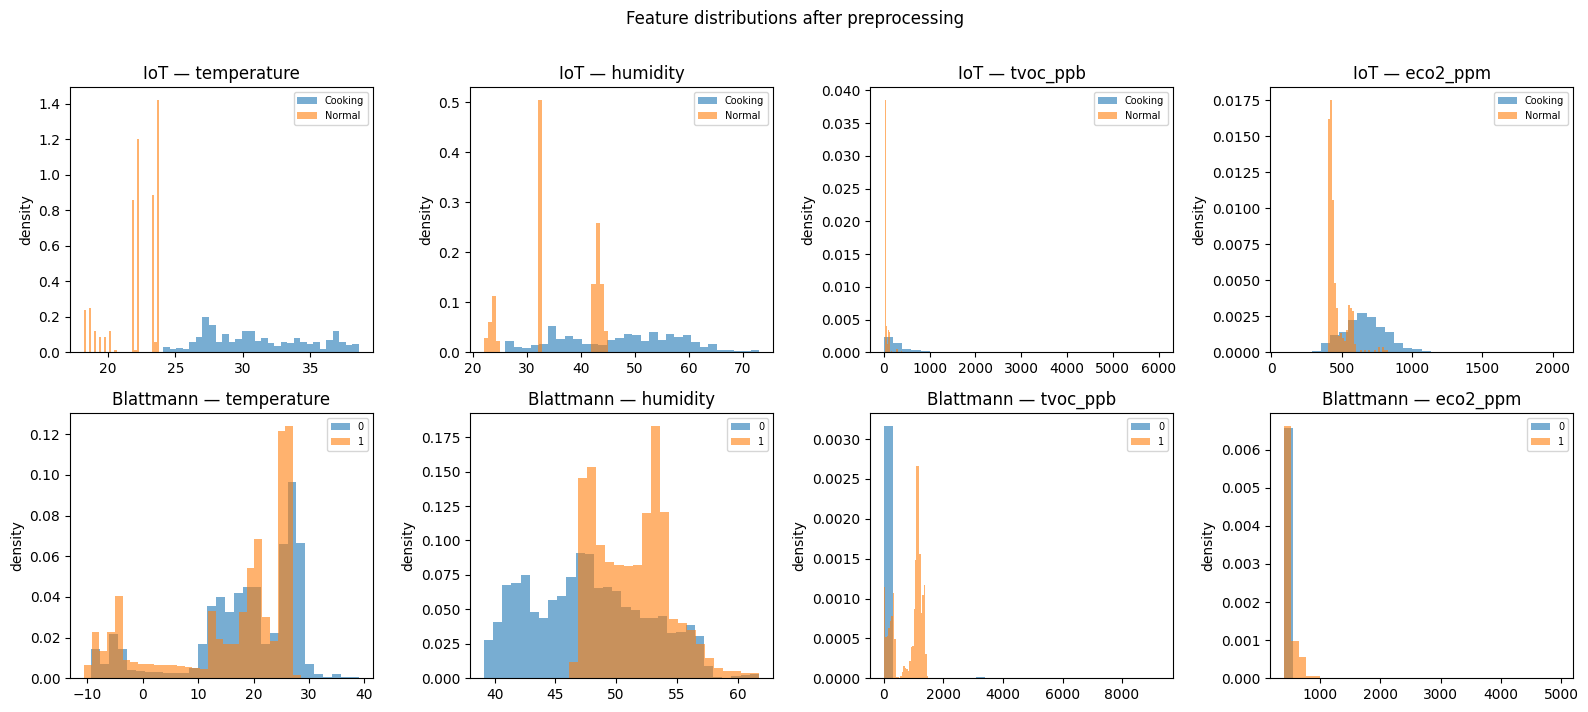

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
FEAT = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']

for col_i, col in enumerate(FEAT):
    for row_i, (name, df, lbl_col) in enumerate([
            ('IoT', iot_clean, 'label'),
            ('Blattmann', blatt_clean, 'fire_alarm')]):
        ax = axes[row_i][col_i]
        for lbl in sorted(df[lbl_col].unique()):
            ax.hist(df[df[lbl_col]==lbl][col], bins=30, alpha=0.6,
                    label=str(lbl), density=True)
        ax.set_title(f'{name} — {col}')
        ax.set_ylabel('density')
        ax.legend(fontsize=7)

plt.suptitle('Feature distributions after preprocessing', y=1.01)
plt.tight_layout()
plt.show()


In [13]:
iot_clean.to_excel(PREPROCESSED_DIR / 'iot_preprocessed.xlsx',       index=False)
blatt_clean.to_excel(PREPROCESSED_DIR / 'blattmann_preprocessed.xlsx', index=False)

print('Saved preprocessed/iot_preprocessed.xlsx     :', iot_clean.shape)
print('Saved preprocessed/blattmann_preprocessed.xlsx:', blatt_clean.shape)


Saved preprocessed/iot_preprocessed.xlsx     : (5080, 7)
Saved preprocessed/blattmann_preprocessed.xlsx: (55132, 5)
